# Markov Chains and its Applications

## Exercise 1: Four-Compartment Mouse Markov Chain

**Problem Statement**

The diagram depicts four connected compartments labelled $1, 2, 3, 4$, with internal doors between compartments. A mouse located in any compartment chooses uniformly at random among all exit doors from its current compartment to move to an adjacent compartment in one discrete time step.

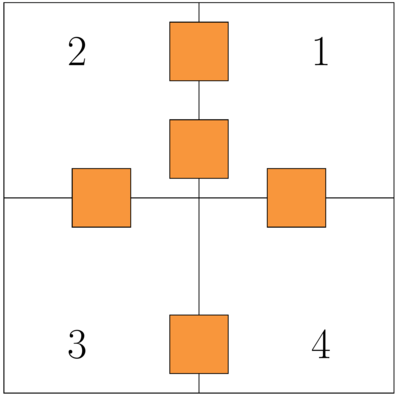

**Task 1.1: Find the Transition Matrix**

To do: replace `...` below to complete the tasks

Let $X_n$ be the location of the mouse after $n$ steps, where $n = 0, 1, 2, ...$
1. Find the transition matrix $\mathbf P = [\mathbf P_{ij}]$ of the Markov Chain $\{X_n\}_{n=0}^\infty$.

2. Verify that $\mathbf P$ is a valid transition matrix.
    - $\mathbf P$ must be a square matrix
    - Each entry of $\mathbf P$ lie between $0$ and $1$
    - Each row sum of $\mathbf P =1$

**Hints:**
- The Markov Chain $\{X_n\}_{n=0}^\infty$ satisfies the Markov memoryless property
$$
\mathbb{P}(X_{n+1} = x_{n+1} \mid X_n = x_n,\: X_{n-1} = x_{n-1},\: \cdots,\: X_0 = x_0 ) = \mathbb{P}(X_{n+1} = x_{n+1} \mid X_n = x_n)
$$
i.e.: Given the present state, the past states have no influence on the future.

- Each entry of the transition matrix $\mathbf P$ is defined as $\mathbf{P}_{ij} = \mathbb{P}(X_{n+1} = j \mid X_n = i)$

- `X.sum(axis=1)` returns the sum of each row of `X`
- `X.shape` returns the number of rows and number of columns of matrix `X`
- `np.allclose(a,b)` checks whether `a` equal to be `b`, taking into floating-point inaccuracies.
- `np.any(X < 0)` returns `True` if at least one element in array `X` is less than $0$, otherwise returns `False`


In [ ]:
import numpy as np
from scipy.linalg import eig

# Task 1.1.1: Find the Transition Matrix
P = np.array([
    ...,
    ...,
    ...,
    ...
])

# Task 1.1.2: Validate Matrix
# Check whether a matrix is a valid transition matrix.

rowsum = ...

rows, cols = ...

if ...:
    print("✗ Transition matrix must be square.")

if ...:
    print(f"✗ Invalid transition matrix. Row sums = {rowsum}")

if ...:
    print("✗ Transition matrix contains negative probabilities.")

else:
    print("✓ Transition matrix is valid.")

**Task 1.2: Plot the transition graph**

This graph visualize the trasisition states and probabilities of the Markov chain.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add nodes for the states (1, 2, 3, 4)
num_states = P.shape[0]
G.add_nodes_from(range(1, num_states + 1))

# Add edges with transition probabilities as weights
for i in range(num_states):
    for j in range(num_states):
        prob = P[i, j]
        if prob > 0:
            G.add_edge(i + 1, j + 1, weight=prob)

# Define positions for the nodes for better visualization
pos = nx.circular_layout(G)

# Draw the nodes
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=1000)

# Draw the edges
nx.draw_networkx_edges(G, pos, arrowsize=20, edge_color='gray', width=2)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Draw edge labels (transition probabilities)
edge_labels = {(u, v): f'{d["weight"]:.2f}' for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Markov Chain Transition Graph")
plt.axis('off') # Hide axes
plt.show()

**Task 1.3: Compute the distributions**

To do: replace `...` below to complete the tasks

Suppose the mouse is located in compartment $2$ initially.

1. Find the initial distribution $\boldsymbol\pi_0 = [\mathbb P(X_0 = 1), \mathbb P(X_0 = 2), \mathbb P(X_0 = 3), \mathbb P(X_0 = 4)]$
2. Find the distribution after $3$ steps $\boldsymbol\pi_3 = [\mathbb P(X_3 = 1), \mathbb P(X_3 = 2), \mathbb P(X_3 = 3), \mathbb P(X_3 = 4)]$

**Hints:**
- Marginal distribution update rule for discrete-time Markov chains:
$$
\boldsymbol{\pi}_n = \boldsymbol{\pi}_{n-1}\mathbf{P}, \quad n = 1, 2, 3, ...
$$

- `A @ B` returns the matrix product $AB$ of `A` and `B`
- `list.append(item)` appends a new item `item` into `list`

In [ ]:
# Task 1.3.1: Define the Initial Distribution
pi0 = ...      # Start in compartment 2

print("Initial distribution:")
print(pi0)

# Task 1.3.2: Define a function that compute Distributions for first n steps
def propagate_distribution(initial_dist, P, n_steps):
    """
    Compute distribution for the first n_steps.
    π_n = π_0 P^n
    """
    distributions = ...      # Initialize a list that stores distributions over time
    current = initial_dist.copy()
    for _ in range(n_steps):
        current = ...
        ...     # Append the current distribution to the list

    return distributions

# Compute Distributions after 3 steps
distributions = ...

for step, dist in enumerate(distributions):
    print(f"\nDistribution at step {step}:")
    print(dist)

**Task 1.4: Find probability of compartment $2$ after $3$ steps**

To do: replace `...` below to complete the task

Find the probability that the mouse is in compartment $2$ after $3$ steps, i.e. $\mathbb P(X_3 = 2)$.

In [ ]:
# Task 1.4: Probability of state 2 after 3 steps
pi3 = ...
prob_state_2 = ...

print(f"Probability mouse is in compartment 2 after 3 steps = {prob_state_2}")

**Task 1.5: Compute the $3$-step transition matrix**

To do: replace `...` below to complete the task

Compute the $3$-step transition matrix $P^3$ of the Markov Chain

**Hint:**
- `np.linalg.matrix_power(X, n)` compute $X^n$ of a matrix $X$

In [ ]:
# Task 1.5: Compute P^3
P3 = ...
print(f"P^3 =\n {P3}")

**Task 1.6: Find the stationary distribution**

To do: replace `...` below to complete the tasks

Find and Verify the stationary distribution $\boldsymbol \pi^*$ of the Markov Chain.

**Hints:**
- Stationary Distribution $\boldsymbol \pi^*$ satisfies
  1. $\boldsymbol \pi^* = \boldsymbol \pi^* \mathbf P \quad \Leftrightarrow \quad \mathbf P^T \boldsymbol \pi^{*T} = \boldsymbol \pi^{*T}$
  2. $\boldsymbol \pi^*$ is a probability row-vector
  \
i.e. $\boldsymbol \pi^*$ is a left 1-eigenvector of $\mathbf P$ in which the entries lie between $0$ and $1$ and sum up to $1$

- `eig(X)` returns a list of all eigenvalues and a list of all eigenvectors of matrix `X`
- `np.argmin(list)` returns the index of the minimum entry in `list`
- `X.sum()` returns the sum of all entries in `X`

In [ ]:
# Task 1.6.1: Find the Stationary Distribution
"""
Solve πP = π
using eigenvector associated with eigenvalue 1.
"""
eigenvalues, eigenvectors = ...          # Find the eigenvlaues and eigenvectors of P
idx = ...      # Find the index corresponding to the eigenvalue 1
stationary = ...   # Find the eigenvector corresponding to the eigenvalue 1
pi_star = ...       # Normalize the left 1-eigenvector of P

print(f"Stationary Distribution = {pi_star}")

In [ ]:
# Task 1.6.2: Verification of the Stationary Distribution
verification = ...

print("π*P:")
print(verification)
print()

if ...:
    print("✓ Stationary distribution verified.")
else:
    print("✗ Verification failed.")

**Task 1.7: Find the Long-run Probability of compartment 2**

To do: replace `...` below to complete the task

Find the probability of the mouse is at compartment 2 in a long run, i.e. $\displaystyle \lim_{n \to \infty} \mathbb P(X_n = 2)$.

**Hint:**
- If stationary distribution exsits, then $\boldsymbol \pi^* = \boldsymbol \pi^* \mathbf P = \boldsymbol \pi^* \mathbf P^n$ for any positive integers $n$.
- If the chain is aperiodic and irreducible, then $\pi^*$ is unique and for any initial distribution $ \pi_0$, $$\boldsymbol \pi^* = \lim_{n \to \infty} \pi_0 \mathbf P^n$$

In [ ]:
# Task 1.7: Find the Long-run probability of compartment 2
long_run_prob = ...

print(f"Long-run probability of compartment 2 = {long_run_prob:.4f}")

## Exercise 2: Two-State Markov Chain Example

**Problem Statement**

Let $\{X_n, n \geq 0\}$ be a discrete-time Markov chain with finite state space $\mathcal S = \{1, 2\}$.
+ Initial marginal distribution at $t = 0: \quad \boldsymbol{\pi}_0 = \begin{pmatrix} \frac{1}{3} & \frac{2}{3} \end{pmatrix}$
+ One-step transition matrix

$$
\mathbf{P} =
\mathop{
    \begin{pmatrix}
        0.5 & 0.5 \\
        0.3 & 0.7
    \end{pmatrix}
}\limits^{\displaystyle \begin{matrix} \text{Destination} \\ 1 \hspace{2.5em} 2 \end{matrix}}
\,
\begin{matrix}
    1 \\
    2
\end{matrix}
\ \ \text{Current State}
$$

**Task 2.1: Input and Verify the Transition Matrix**

To do: replace `...` below to complete the tasks

Verify that $\mathbf P$ is a valid transition matrix.
1. $\mathbf P$ must be a square matrix
2. Each entry of $\mathbf P$ lie between $0$ and $1$
3. Each row sum of $\mathbf P =1$

In [ ]:
import numpy as np

# Task 2.1.1: Input the transition matrix

P = np.array(
    [
        ...,
        ...
    ]
)

print("Transition Matrix P")
print(P)

# Task 2.1.2: Validate the transition matrix
rows, cols = ...
row_sums = ...

if ...:
    print("✗ Transition matrix must be square.")

if ...:
    print("✗ Transition matrix contains negative entries.")

if ...:
    print(f"Rows do not sum to 1.\nRow sums = {row_sums}")

print("✓ Transition matrix is valid.")

**Task 2.2: Plot the transition graph**

This graph visualize the trasisition states and probabilities of the Markov chain.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G_q2 = nx.DiGraph()

# Add nodes for the states (1, 2)
num_states_q2 = P.shape[0]
G_q2.add_nodes_from(range(1, num_states_q2 + 1))

# Define positions for the nodes
pos_q2 = {1: (-0.5, 0), 2: (0.5, 0)}

# Increase figure size for better visibility
fig, ax = plt.subplots(figsize=(8, 4))

# Draw the nodes
nx.draw_networkx_nodes(G_q2, pos_q2, node_color='lightcoral', node_size=2000, ax=ax)

# Draw node labels
nx.draw_networkx_labels(G_q2, pos_q2, font_size=14, font_weight='bold', ax=ax)

# Style for the label backgrounds
bbox_style = dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2')

# ---------------------------------------------------------------------------
# INTER-NODE EDGES
# ---------------------------------------------------------------------------

# 1. Draw inter-node edge (1 -> 2)
ax.annotate("",
            xy=pos_q2[1], xycoords='data',
            xytext=pos_q2[2], textcoords='data',
            arrowprops=dict(arrowstyle="<-", color="gray", lw=2,
                            shrinkA=25, shrinkB=25,
                            connectionstyle="arc3,rad=0.3"))
# Label for 1 -> 2 (Top)
ax.text(0, 0.15, f'{P[0, 1]:.2f}', ha='center', va='center',
        color='blue', fontsize=12, fontweight='bold', bbox=bbox_style)

# 2. Draw inter-node edge (2 -> 1)
ax.annotate("",
            xy=pos_q2[2], xycoords='data',
            xytext=pos_q2[1], textcoords='data',
            arrowprops=dict(arrowstyle="<-", color="gray", lw=2,
                            shrinkA=25, shrinkB=25,
                            connectionstyle="arc3,rad=0.3"))
# Label for 2 -> 1 (Bottom)
ax.text(0, -0.15, f'{P[1, 0]:.2f}', ha='center', va='center',
        color='blue', fontsize=12, fontweight='bold', bbox=bbox_style)

# ---------------------------------------------------------------------------
# SELF-LOOPS (Fixed)
# ---------------------------------------------------------------------------

# 3. Draw self-loop for node 1 (Sideways to the Left)
# We start slightly above center on the left edge, and end slightly below
ax.annotate("",
            xy=(-0.56, -0.04), xycoords='data',      # Bottom-left edge
            xytext=(-0.56, 0.04), textcoords='data', # Top-left edge
            arrowprops=dict(arrowstyle="->", color="gray", lw=2,
                            # armA/armB project West (180 deg) by 30 points, rad connects them
                            connectionstyle="arc,angleA=180,angleB=180,armA=30,armB=30,rad=15"))
# Label for 1 -> 1 (Left side)
ax.text(-0.76, 0, f'{P[0, 0]:.2f}', ha='center', va='center',
        color='darkgreen', fontsize=12, fontweight='bold', bbox=bbox_style)

# 4. Draw self-loop for node 2 (Sideways to the Right)
# We start slightly above center on the right edge, and end slightly below
ax.annotate("",
            xy=(0.56, -0.04), xycoords='data',      # Bottom-right edge
            xytext=(0.56, 0.04), textcoords='data', # Top-right edge
            arrowprops=dict(arrowstyle="->", color="gray", lw=2,
                            # armA/armB project East (0 deg) by 30 points, rad connects them
                            connectionstyle="arc,angleA=0,angleB=0,armA=30,armB=30,rad=15"))
# Label for 2 -> 2 (Right side)
ax.text(0.76, 0, f'{P[1, 1]:.2f}', ha='center', va='center',
        color='darkgreen', fontsize=12, fontweight='bold', bbox=bbox_style)

# Expand plot limits slightly so the loops don't get cut off at the edges
ax.set_xlim(-1.0, 1.0)
ax.set_ylim(-0.4, 0.4)

plt.title("Markov Chain Transition Graph")
plt.axis('off') # Hide axes
plt.tight_layout()
plt.show()

**Task 2.3: Compute the $m$-step transition matrices**

To do: replace `...` below to complete the task

Compute the $2$-step, $3$-step and $12$-step transition matrices $P^2$, $P^3$, $P^{12}$ of the Markov Chain.

In [ ]:
# Task 2.3: Compute P^2, P^3 and P^12
P2 = ...
P3 = ...
P12 = ...

print(f"P^2 =\n {P2}\n")
print(f"P^3 =\n {P3}\n")
print(f"P^12 =\n {P12}")

**Task 2.4: Find the Joint Path Probability**

To do: replace `...` below to complete the task

Compute the joint path probability:

$$
\mathbb P(X_1 = 2, X_4 = 1, X_6 = 1, X_{18} = 1 \mid X_0 = 1)
$$

**Hints:**
- By Markov memoryless property,
\begin{align*}
\mathbb{P}&\big(X_1 = 2, X_4 = 1, X_6 = 1, X_{18} = 1 \mid X_0 = 1\big) \\
&= \underbrace{\mathbb{P}(X_1 = 2 \mid X_0 = 1)}_{\mathbf{P}_{12}} \times \underbrace{\mathbb{P}(X_4 = 1 \mid X_1 = 2)}_{\mathbf{P}_{21}^3} \times \underbrace{\mathbb{P}(X_6 = 1 \mid X_4 = 1)}_{\mathbf{P}_{11}^2} \times \underbrace{\mathbb{P}(X_{18} = 1 \mid X_6 = 1)}_{\mathbf{P}_{11}^{12}}
\end{align*}
(Note: An $m$-step transition matrix satisfy $\mathbb P(X_{n+m} = j \mid X_{n} = i) = \mathbf P^m_{ij}$)

In [ ]:
# Task 2.4.1: Extract the required probabilities
# P(X_1 = 2 | X_0 = 1)
p12 = ...

# P(X_4 = 1 | X_1 = 2)
p3_21 = ...

# P(X_6 = 1 | X_4 = 1)
p2_11 = ...

# P(X_18 = 1 | X_6 = 1)
p12_11 = ...

print(f"P_12      = {p12:.4f}")
print(f"(P^3)_21  = {p3_21:.4f}")
print(f"(P^2)_11  = {p2_11:.4f}")
print(f"(P^12)_11 = {p12_11:.4f}")

# Task 2.4.2: Find the Final Joint Probability
joint_probability = ...

print(f"\nP(X_1 = 2, X_4 = 1, X_6 = 1, X_18 = 1 | X_0 = 1) = {joint_probability:.4f}")

**Task 2.5: Find the Stationary Distribution**

To do: replace `...` below to complete the tasks

Find and Verify the stationary distribution $\boldsymbol \pi^*$ of the Markov Chain.

In [ ]:
# Task 2.5.1: Find the Stationary Distribution
"""
Solve πP = π
using eigenvector associated with eigenvalue 1.
"""
eigenvalues, eigenvectors = ...          # Find the eigenvlaues and eigenvectors of P
idx = ...      # Find the index corresponding to the eigenvalue 1
stationary = ...    # Find the eigenvector corresponding to the eigenvalue 1
pi_star = ...      # Normalize the left 1-eigenvector of P

print(f"Stationary Distribution = {pi_star}")

In [ ]:
# Task 2.5.2: Verification of the Stationary Distribution
verification = ...

print("π*P:")
print(verification)
print()

if ...:
    print("✓ Verified:  πP = π")
else:
    print("✗ Verification failed.")

## Example 3: Hong Kong Weather Markov Chain Example

**Problem Statement**

Suppose the weather system in Hong Kong can be simplified to three mutually exclusive discrete states:
1. Cloudy
2. Sunny
3. Rainy

Further suppose that tomorrow's weather state probability distribution depends **only** on today's observed weather state, with no dependence on historical weather prior to the current day. (i.e. Markov memoryless property)

The state diagram is shown below:

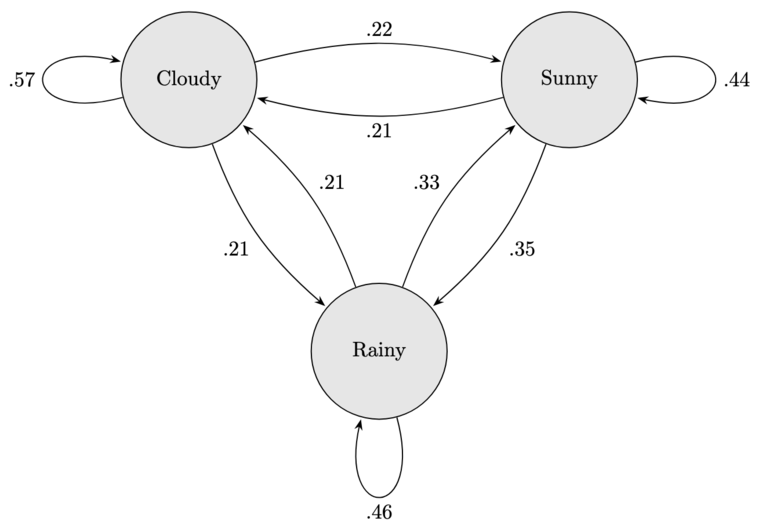

**Task 3.1: Find the Transition Matrix**

To do: replace `...` below to complete the task

Find the one-step transition matrix $\mathbf P$ of the Markov Chain where rows represent the current weather state and columns represent the subsequent day's weather state.

In [ ]:
import numpy as np
# Task 3.1: Define the transition matrix
# Rows = current state, Columns = next state
# States: [Cloudy, Sunny, Rainy]
transmat = np.array([
    ...,  # Cloudy row
    ...,  # Sunny row
    ...   # Rainy row
])

print(f"Transition Matrix:\n", transmat)

**Task 3.2: Find the initial state vector**

To do: replace `...` below to complete the task

Initially on November $12$, $2020$, the observed noon weather state is Cloudy. Find the initial state vector.

In [ ]:
# Task 3.2: Define the initial state vector
# November 12, 2020 = Cloudy
state0 = ...  # Cloudy = 1, Sunny = 0, Rainy = 0

print(f"State vector at day 0:", state0)

**Task 3.3: Create a Forecast Function**

To do: replace `...` below to complete the task

Create a Forecast function `forecast(transmat, state0, n_steps)` which takes three inputs:

- `transmat`: The one-step transition matrix
- `state0`: The initial state vector
- `n_steps`: Number of steps to forecast

The function should have two outputs:

- `transmat_n`: The `n`-step transition matrix
- `state_n`: The forecasted state vector

**Hint:**
- Marginal distribution update rule:
$$
\boldsymbol{\pi}_n = \boldsymbol{\pi}_0\mathbf{P}^n, \quad n = 1, 2, 3, ...
$$

In [ ]:
# Task 3.3: Forecast function
def forecast(transmat, state0, n_steps):
    transmat_n = ...    # Raise transition matrix to the nth power
    state_n = ...                             # Multiply by initial state vector
    return transmat_n, state_n

**Task 3.4: Compute the forecast**

To do: replace `...` below to complete the task

Compute the forecasted state vector for $1, 2, 3$ days ahead and the corresponding transition matrices

In [ ]:
# Task 3.4: Compute forecasts for 1, 2, 3 days ahead
for n in range(1, 4):
    transmat_n, state_n = ...
    print(f"Transition Matrix ^ {n}:\n", transmat_n, "\n")
    print(f"State vector at day {n}:\n", state_n, "\n")

**Task 3.5: Interpretation of the forecast**

To do: replace `...` below to complete the task

Forecast weather conditions on November $15$, three days after the initial observation ($t = 3$).

In [ ]:
# Task 3.5: Interpretation
labels = ["Cloudy", "Sunny", "Rainy"]
transmat3, state3 = ...

print("--- Forecast for November 15 (3 days ahead) ---")
for label, prob in zip(labels, state3):
    print(f"{label}: {prob:.2f} ({prob*100:.0f}%)")

## Example 4: Hypothetical 3-State Market Markov Chain Example

**Problem Statement**

We analyze a hypothetical weekly market regime system satisfying the Markov memoryless property, with empirically derived transition probabilities sourced from historical market observations.

The state diagram is shown below:

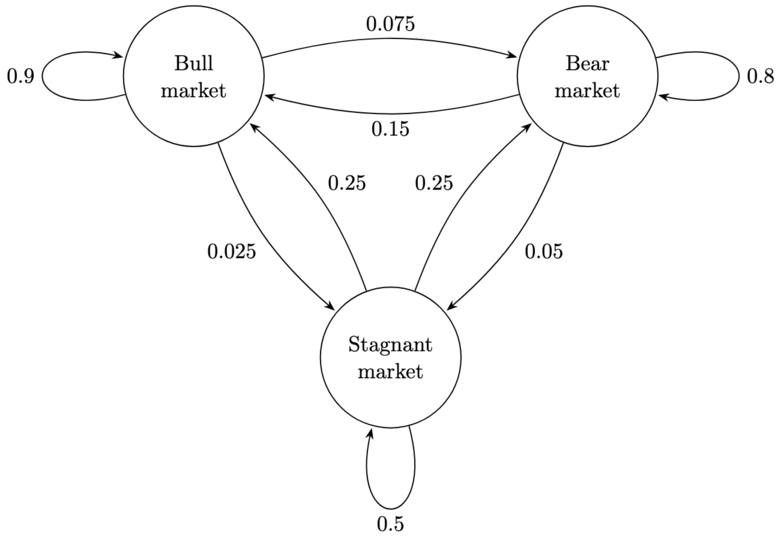



**Task 3.1: Find the Transition Matrix**

To do: replace `...` below to complete the task

Find the one-step transition matrix $\mathbf P$ of the Markov Chain where rows represent the current market state and columns represent the subsequent day's market state.

In [ ]:
import numpy as np

# Task 4.1: Define the transition matrix
# Rows = current state, Columns = next state
# States: [Bull, Bear, Stagnant]
transmat = np.array([
    ...,  # Bull row
    ...,  # Bear row
    ...   # Stagnant row
])

print(f"Transition Matrix:\n", transmat)

**Task 4.2: Find the initial state vector**

To do: replace `...` below to complete the task

We initialize the system with a bear market in the current week. Find the initial state vector.

In [ ]:
# Task 4.2: Define the initial state row vector
# Current week = Bear market
state0 = ...  # Bull = 0, Bear = 1, Stagnant = 0

print(f"State vector at day 0:", state0)

**Task 4.3: Create a Forecast Function**

To do: replace `...` below to complete the task

Create a Forecast function `forecast(transmat, state0, n_steps)` which takes three inputs:

- `transmat`: The one-step transition matrix
- `state0`: The initial state vector
- `n_steps`: Number of steps to forecast

The function should have two outputs:

- `transmat_n`: The `n`-step transition matrix
- `state_n`: The forecasted state vector

**Hint:**
- Marginal distribution update rule:
$$
\boldsymbol{\pi}_n = \boldsymbol{\pi}_0\mathbf{P}^n, \quad n = 1, 2, 3, ...
$$

In [ ]:
# Task 4.3: Forecast function
def forecast(transmat, state0, n_steps):
    transmat_n = ...    # Raise transition matrix to the nth power
    state_n = ...                             # Multiply by initial state vector
    return transmat_n, state_n

**Task 4.4: Compute the forecast**

To do: replace `...` below to complete the task

Compute the forecasted state vector for $1, 5, 52, 99$ weeks ahead and the corresponding transition matrices

In [ ]:
# Task 4.4: Compute forecasts for 1, 5, 52, 99 weeks ahead
for n in ...:
    transmat_n, state_n = ...
    print(f"Transition Matrix ^ {n}:\n", transmat_n, "\n")
    print(f"State vector at week {n}:\n", state_n, "\n")

**Task 4.5: Find the Stationary Distribution**

To do: replace `...` below to complete the tasks

Find the stationary distribution $\boldsymbol \pi^*$ of the Markov Chain.

**Hints:**
- Stationary Distribution $\boldsymbol \pi^*$ satisfies
  1. $\boldsymbol \pi^* = \boldsymbol \pi^* \mathbf P \quad \Leftrightarrow \quad (\mathbf P^T - \mathbf I) \boldsymbol \pi^{*T} = \boldsymbol 0$
  2. $\boldsymbol \pi^*$ is a probability row-vector
  \
i.e. $\boldsymbol \pi^*$ is a nontrivial solution of the system in 1. in which the entries lie between $0$ and $1$ and sum up to $1$

- `X.T` returns the transpose of matrix `X`
- `np.eye(k)` returns a `k` $\times$ `k` Identity matrix
- The condition in which the entries of $\boldsymbol \pi^*$ sum up to $1$ is equivalent to $\quad [1, 1, 1] \boldsymbol \pi^{*T} = 1$
- `np.ones(k)` returns an array of `k` entries with value $1$
- `np.vstack([X, Y])` stacks the arrays `X` and `Y` vertically (row-wise) to combine them into a single array
- `solution, _, _, _ = np.linalg.lstsq(A, b, rcond=None)` solves for the least-square solution `solution` of the system $\mathbf A \mathbf x=\mathbf b$ (which always exists)

In [ ]:
# Task 4.5: Compute stationary distribution
# Solve π such that π * transmat = π and sum(π)=1
# Transpose for solving linear system: (transmat.T - I)π.T = 0
A = ...
A = ...    # Add normalization constraint
b = ...

# Solve least squares system
pi, _, _, _ = ...

print("--- Stationary Distribution ---")
labels = ["Bull", "Bear", "Stagnant"]
for label, prob in zip(labels, pi):
    print(f"{label}: {prob:.2f} ({prob*100:.0f}%)")